# Estudio comparativo de modelos de aprendizaje profundo para el procesamiento de documentación logística industrial
# Daniel Hidalgo Ocaña - Baseline sobre CORD (modelos preentrenados)

<br><br>

---

<br><br>

## Objetivo

<br><br>

El propósito de este cuaderno es establecer una referencia inicial del rendimiento de los tres enfoques analizados utilizando el conjunto de datos público **CORD (Consolidated Receipt Dataset)** y los modelos disponibles en sus respectivas versiones preentrenadas. Este punto de partida permite evaluar posteriormente el impacto de la adaptación al dominio logístico mediante procesos de ajuste fino (*fine-tuning*) sobre albaranes.

<br><br>

### Alcance del experimento

Los modelos **DONUT** (`naver-clova-ix/donut-base-finetuned-cord-v2`) y **LayoutLMv3** (`nielsr/layoutlmv3-finetuned-cord`) han sido previamente entrenados y ajustados utilizando el conjunto de datos CORD. En consecuencia, los resultados obtenidos en este escenario reflejan el comportamiento esperado de los modelos dentro de su dominio de especialización.

Por su parte, **PaddleOCR** se emplea como una solución basada en reconocimiento óptico de caracteres complementada mediante expresiones regulares para la extracción de información, sin incorporar mecanismos específicos de extracción de entidades entrenados sobre el conjunto de datos.

El interés de este experimento no reside en determinar qué modelo ofrece el mejor rendimiento sobre CORD, sino en disponer de una referencia comparativa que permita analizar posteriormente la pérdida de rendimiento al aplicar estos modelos sobre documentación logística real sin adaptación previa, así como la mejora obtenida tras el proceso de ajuste al nuevo dominio.

<br><br>

### Criterios de diseño experimental

Con el objetivo de garantizar la consistencia metodológica y facilitar la comparación con el resto de experimentos desarrollados en este trabajo, se han adoptado las siguientes decisiones:

- **Imágenes sin degradación visual (severidad 0).** La evaluación de la robustez frente a ruido, distorsiones y otros factores de degradación se aborda en cuadernos específicos dedicados a dicho análisis.

- **Extracción de un único campo objetivo:** `total.total_price`, correspondiente al importe total del recibo dentro del esquema de anotaciones de CORD.

- **Conjunto de muestras idéntico para los tres modelos**, empleando una semilla fija para garantizar la reproducibilidad de los resultados y evitar variaciones derivadas de selecciones aleatorias.

- **Procesamiento corregido de las predicciones de LayoutLMv3**, agrupando los subtokens consecutivos asociados al valor del importe total para reconstruir correctamente la entidad completa.

- **Metodología de benchmarking unificada**, utilizando el procedimiento `medir_recursos` y almacenando los resultados en `benchmark_costes.json`, identificados con la etiqueta `dataset='CORD'` para diferenciarlos de los experimentos realizados sobre documentación logística.

- **Aislamiento del consumo de memoria gráfica (VRAM)** durante la evaluación de cada modelo, liberando completamente los recursos antes de cargar el siguiente sistema.

## 00 - Configuracion y entorno

In [1]:
# ==============================================================================
# 00.1 - INSTALACION (Google Colab)
# ==============================================================================

!pip install -q --upgrade pip wheel "setuptools<82"
!pip install -q datasets==2.19.0 transformers accelerate torchvision
!pip install -q "jiwer==3.0.3" "python-Levenshtein==0.25.1" tabulate tqdm pandas seaborn matplotlib psutil
# OCR para PaddleOCR (baseline en cascada)
!python -m pip install -q paddlepaddle-gpu
!pip install -q "paddleocr==2.7.3"
# --- Tesseract para LayoutLMv3: el processor usa apply_ocr=True y OCR-ea internamente.
#     Hacen falta el binario del sistema Y el wrapper de python. CORD es ingles -> 'eng' (incluido).
!apt-get install -y -q tesseract-ocr
!pip install -q pytesseract
# --- FIX ABI: PaddleOCR/cv2 estan compilados contra NumPy 1.x. Forzar 1.x AL FINAL
#     para que gane la resolucion de dependencias.
#     Sin esto: "module compiled against ABI version 0x1000009 ... numpy is 0x2000000"
#     -> "numpy.core.multiarray failed to import" al hacer `from paddleocr import PaddleOCR`.
!pip install -q "numpy==1.26.4"

print("Entorno baseline preparado.")
print("IMPORTANTE: Runtime -> Restart session ANTES de seguir")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 which is incompatible.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for Levenshtein (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> No available output.
 

**Reinicio obligatorio.**


In [1]:
# ==============================================================================
# 00.2 - DRIVE + IMPORTS + GPU
# ==============================================================================

from google.colab import drive
drive.mount('/content/drive')

import os, time, json, gc
import numpy as np, torch
import matplotlib.pyplot as plt
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0)); torch.cuda.reset_peak_memory_stats()
else:
    print('AVISO: sin GPU; en Colab selecciona T4.')


Mounted at /content/drive
Device: cuda
GPU: Tesla T4


In [2]:
# ==============================================================================
# 00.3 - CONFIGURACION CENTRALIZADA
# ==============================================================================

DRIVE_ROOT = "/content/drive/MyDrive/STUDIES/MASTER/2Q/TFM"
CONFIG = {
    "RESULTS_DIR": f"{DRIVE_ROOT}/03__Resultados",
    "BENCH_PATH":  f"{DRIVE_ROOT}/03__Resultados/benchmark_costes.json",
    "N_DOCS": 100,          # nº de recibos CORD a evaluar (split test, determinista)
    "SEED": 42,
}
os.makedirs(CONFIG['RESULTS_DIR'], exist_ok=True)

print('Config lista.')


Config lista.


## 01 -  Métricas y benchmarking

Este bloque implementa las funciones auxiliares empleadas durante la evaluación de los modelos.

En primer lugar, se definen los procedimientos de normalización y las métricas utilizadas para comparar los valores predichos con la referencia real del campo `total.total_price`. Concretamente, se calculan:

- **CER (Character Error Rate)**.
- **ANLS (Average Normalized Levenshtein Similarity)**.
- **Precisión, exhaustividad y F1-Score**.

Adicionalmente, se incorpora un sistema de benchmarking común a todos los experimentos, encargado de registrar:

- Tiempo de ejecución.
- Utilización de CPU.
- Consumo de memoria RAM.
- Consumo de memoria GPU (VRAM), cuando está disponible.
- Operaciones de lectura y escritura en disco.

Los resultados se almacenan de forma estructurada para facilitar la comparación objetiva entre los distintos enfoques evaluados. En este cuaderno, las mediciones corresponden exclusivamente a la fase de inferencia sobre el conjunto de datos CORD utilizando modelos preentrenados.

In [4]:
# ==============================================================================
# 01 - UTILIDADES (metricas + benchmarking)
# ==============================================================================

import re, json, os
import numpy as np
import jiwer, Levenshtein

def normalizar_precio(texto):
    texto = str(texto).strip().lower()
    texto = re.sub(r'[^\d.,]', '', texto)
    if not texto:
        return ""
    if '.' in texto and ',' in texto:
        if texto.rfind(',') > texto.rfind('.'):
            texto = texto.replace('.', '').replace(',', '.')
        else:
            texto = texto.replace(',', '')
    elif ',' in texto and '.' not in texto:
        partes = texto.split(',')
        texto = ("".join(partes[:-1]) + "." + partes[-1]) if (len(partes) > 2 and len(partes[-1]) == 3) else texto.replace(',', '.')
    try:
        texto = re.sub(r'\.+', '.', texto)
        v = float(texto)
        return str(int(v)) if v.is_integer() else str(v)
    except ValueError:
        return texto

def calcular_cer(gt, pred):
    r, h = normalizar_precio(gt), normalizar_precio(pred)
    if len(r) == 0:
        return 1.0 if len(h) > 0 else 0.0
    return min(jiwer.cer(r, h), 1.0)

def calcular_anls(gt, pred, umbral=0.5):
    r, h = normalizar_precio(gt), normalizar_precio(pred)
    if not r:
        return 1.0 if not h else 0.0
    L = max(len(r), len(h))
    if L == 0:
        return 1.0
    nl = Levenshtein.distance(r, h) / L
    return (1.0 - nl) if nl < umbral else 0.0

def calcular_tp_fp_fn(gt, pred):
    g, p = normalizar_precio(gt), normalizar_precio(pred)
    if g == p and g != "":  return 1, 0, 0
    if g != "" and p == "": return 0, 0, 1
    if g == "" and p != "": return 0, 1, 0
    if g != "" and p != "" and g != p: return 0, 1, 1
    return 0, 0, 0

def prf(tp, fp, fn):
    p = tp/(tp+fp) if tp+fp else 0.0
    r = tp/(tp+fn) if tp+fn else 0.0
    return p, r, (2*p*r/(p+r) if p+r else 0.0)

print('Metricas listas.')

# ==============================================================================
# BENCHMARKING: medición de recursos computacionales
# ==============================================================================

# Registro unificado de tiempo de ejecución, CPU, RAM, VRAM y E/S para todos los
# experimentos. En el baseline únicamente se evalúa la inferencia sobre CORD con
# modelos preentrenados. Los resultados se etiquetan con el modelo y el dataset
# utilizado para facilitar su comparación con los experimentos del dominio logístico.

import threading, time as _time, json as _json, os as _os

class _MuestreadorCPU(threading.Thread):
    def __init__(self, proc, intervalo=0.5):
        super().__init__(daemon=True)
        self.proc=proc; self.intervalo=intervalo; self.muestras=[]; self._evt=threading.Event()
    def run(self):
        try: self.proc.cpu_percent(None)
        except Exception: pass
        while not self._evt.is_set():
            try: self.muestras.append(self.proc.cpu_percent(None))
            except Exception: pass
            self._evt.wait(self.intervalo)
    def detener(self): self._evt.set()

class medir_recursos:
    def __init__(self, fase, n_items=None, results_path=None, extra=None, sample_cpu=True):
        self.fase=fase; self.n_items=n_items
        self.results_path=results_path or CONFIG['BENCH_PATH']
        self.extra=extra or {}; self.sample_cpu=sample_cpu; self.record={}
    def __enter__(self):
        import psutil
        self.psutil=psutil; self.proc=psutil.Process(_os.getpid())
        try:
            import torch; self.torch=torch; self.cuda=torch.cuda.is_available()
        except Exception:
            self.torch=None; self.cuda=False
        if self.cuda:
            self.torch.cuda.synchronize(); self.torch.cuda.reset_peak_memory_stats()
        try: self.io0=self.proc.io_counters()
        except Exception:
            try: self.io0=psutil.disk_io_counters()
            except Exception: self.io0=None
        self.ram0=self.proc.memory_info().rss
        self.sampler=_MuestreadorCPU(self.proc) if self.sample_cpu else None
        if self.sampler: self.sampler.start()
        self.t0=_time.time(); return self
    def __exit__(self, *a):
        dt=_time.time()-self.t0
        if self.cuda: self.torch.cuda.synchronize()
        if self.sampler: self.sampler.detener(); self.sampler.join(timeout=2)
        cpu=(sum(self.sampler.muestras)/len(self.sampler.muestras)) if (self.sampler and self.sampler.muestras) else None
        ram1=self.proc.memory_info().rss
        io_r=io_w=None
        try:
            io1=self.proc.io_counters() if hasattr(self.proc,'io_counters') else self.psutil.disk_io_counters()
            if self.io0 is not None:
                io_r=getattr(io1,'read_bytes',0)-getattr(self.io0,'read_bytes',0)
                io_w=getattr(io1,'write_bytes',0)-getattr(self.io0,'write_bytes',0)
        except Exception: pass
        vram=(self.torch.cuda.max_memory_allocated()/(1024**2)) if self.cuda else None
        self.record={'fase':self.fase,'modelo':self.extra.get('modelo','?'),'dataset':self.extra.get('dataset','CORD'),
            'tiempo_s':round(dt,3),'n_items':self.n_items,
            's_por_item':round(dt/self.n_items,4) if self.n_items else None,
            'cpu_pct_medio':round(cpu,1) if cpu is not None else None,
            'ram_proc_mb_fin':round(ram1/(1024**2),1),
            'ram_proc_delta_mb':round((ram1-self.ram0)/(1024**2),1),
            'vram_pico_mb':round(vram,1) if vram is not None else None,
            'disk_read_mb':round(io_r/(1024**2),2) if io_r is not None else None,
            'disk_write_mb':round(io_w/(1024**2),2) if io_w is not None else None,
            **{k:v for k,v in self.extra.items() if k not in ('modelo','dataset')}}
        try:
            data=[]
            if _os.path.exists(self.results_path):
                with open(self.results_path) as f: data=_json.load(f)
            data.append(self.record)
            with open(self.results_path,'w') as f: _json.dump(data,f,ensure_ascii=False,indent=2)
        except Exception as e:
            print('  (aviso: no se pudo persistir el registro de coste:', e, ')')
        print(f"[BENCH] {self.fase}/{self.record['modelo']}: {dt:.2f}s"
              +(f" ({self.record['s_por_item']}s/item)" if self.n_items else '')
              +(f" | CPU~{self.record['cpu_pct_medio']}%" if cpu is not None else '')
              +(f" | VRAM {self.record['vram_pico_mb']}MB" if vram is not None else ' | VRAM n/a'))
        return False

print('medir_recursos() lista (Baseline CORD).')


ModuleNotFoundError: No module named 'jiwer'

## 02 - Carga determinista de CORD

Carga del conjunto de prueba de CORD y selección reproducible de una muestra de tamaño `N_DOCS`. Para cada documento se extrae el campo `total.total_price` y las anotaciones de texto y posición proporcionadas por el propio dataset.

Las mismas imágenes, etiquetas y anotaciones se utilizan posteriormente en la evaluación de los tres modelos.

In [ ]:
# ==============================================================================
# 02 - CORD test set (determinista) + OCR DORADO (words+boxes de CORD)
# ==============================================================================

import json, random
from datasets import load_dataset

cord = load_dataset('naver-clova-ix/cord-v2', split='test')
random.seed(CONFIG['SEED'])
indices = list(range(len(cord)))
random.shuffle(indices)
indices = sorted(indices[:CONFIG['N_DOCS']])

def _gt(sample):
    return json.loads(sample['ground_truth'])

def gt_total(gt):
    try:
        return str(gt['gt_parse']['total']['total_price'])
    except (KeyError, TypeError):
        return ''

def cord_words_boxes(gt, w, h):
    # OCR DORADO de CORD: palabras + cajas anotadas (las que vio el modelo al entrenar).
    # quad {x1..y4} en pixeles originales -> [x0,y0,x1,y1] normalizado 0..1000 (formato LayoutLMv3).
    words, boxes = [], []
    for line in gt.get('valid_line', []):
        for wd in line.get('words', []):
            t = str(wd.get('text', '')).strip()
            if not t:
                continue
            q = wd['quad']
            xs = [q['x1'], q['x2'], q['x3'], q['x4']]
            ys = [q['y1'], q['y2'], q['y3'], q['y4']]
            box = [min(xs), min(ys), max(xs), max(ys)]
            box = [max(0, min(1000, int(1000 * box[0] / w))), max(0, min(1000, int(1000 * box[1] / h))),
                   max(0, min(1000, int(1000 * box[2] / w))), max(0, min(1000, int(1000 * box[3] / h)))]
            words.append(t); boxes.append(box)
    return words, boxes

muestras = []
for i in indices:
    s = cord[i]
    gt = _gt(s)
    g = gt_total(gt)
    if not g:            # solo recibos con total_price en el GT
        continue
    img = s['image'].convert('RGB')
    words, boxes = cord_words_boxes(gt, *img.size)
    muestras.append({'image': img, 'gt_total': g, 'words': words, 'boxes': boxes})

_vacios = sum(1 for m in muestras if not m['words'])
print(f"CORD test: {len(muestras)} recibos con total_price (semilla {CONFIG['SEED']}).")
print(f"OCR dorado adjunto | recibos sin words en el GT: {_vacios}")


CORD test: 95 recibos con total_price (semilla 42).
OCR dorado adjunto | recibos sin words en el GT: 0


## 03 - Paradigma 1: PaddleOCR + expresiones regulares

Implementación de una línea base basada en OCR genérico y extracción mediante expresiones regulares. El sistema procesa cada documento con PaddleOCR y localiza el importe total a partir del texto reconocido.

Este enfoque no requiere entrenamiento ni adaptación al dominio, por lo que sirve como referencia para comparar los modelos basados en aprendizaje profundo.

In [ ]:
# ==============================================================================
# 03 - PADDLEOCR -> pred_paddle (lista alineada con 'muestras')
# ==============================================================================

import re, gc, torch
from paddleocr import PaddleOCR
from tqdm.auto import tqdm

ocr = PaddleOCR(use_angle_cls=True, lang='en', show_log=False)   # CORD = recibos en ingles

def total_por_regex(texto):
    # prioriza 'TOTAL' al pie; evita 'subtotal'/'total qty'
    m = re.search(r'(?<![a-z])TOTAL(?!\s*(?:qty|item))[^\d\-]{0,12}([\d.,]+)', texto, re.IGNORECASE)
    if not m:
        mm = list(re.finditer(r'([\d][\d.,]{2,})', texto))
        return mm[-1].group(1) if mm else ''
    return m.group(1)

pred_paddle = []
with medir_recursos('inference_test', n_items=len(muestras), extra={'modelo': 'PaddleOCR', 'dataset': 'CORD'}):
  for m in tqdm(muestras, desc='PaddleOCR'):
      arr = np.array(m['image'])[:, :, ::-1]
      res = ocr.ocr(arr, cls=True)
      texto = ' '.join(l[1][0] for l in res[0]) if (res and res[0]) else ''
      pred_paddle.append(total_por_regex(texto))

# Liberación de memoria antes de evaluar el siguiente modelo
# para aislar las medidas de consumo de recursos.
del ocr; gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
print('PaddleOCR done. Ejemplos:', list(zip([m['gt_total'] for m in muestras[:3]], pred_paddle[:3])))


PaddleOCR:   0%|          | 0/95 [00:00<?, ?it/s]

[BENCH] inference_test/PaddleOCR: 23.46s (0.247s/item) | CPU~97.7% | VRAM 0.0MB
PaddleOCR done. Ejemplos: [('60.000', '60.000'), ('91000', '91000'), ('28,000', '28.000')]


## 04 - Paradigma 2: LayoutLMv3

Evaluación de LayoutLMv3 utilizando el modelo `nielsr/layoutlmv3-finetuned-cord`, previamente ajustado sobre el conjunto de datos CORD.

La inferencia se realiza a partir de las palabras y coordenadas proporcionadas por las anotaciones del dataset, evitando el uso de motores OCR externos. Para reconstruir el valor del importe total, se agregan todas las palabras consecutivas clasificadas como pertenecientes a la entidad `TOTAL_PRICE`.

In [ ]:
# ==============================================================================
# 04 - LAYOUTLMV3 (nielsr/layoutlmv3-finetuned-cord) -> pred_layout
#      INPUT NATIVO: OCR dorado de CORD (apply_ocr=False). NO usa Tesseract.
# ==============================================================================

import gc, torch
from transformers import LayoutLMv3Processor, LayoutLMv3ForTokenClassification
from tqdm.auto import tqdm

# Se emplea el OCR dorado incluido en CORD (palabras y coordenadas anotadas).
# No se utiliza OCR externo durante la inferencia, garantizando unas condiciones
# de evaluación coherentes con el entrenamiento original de LayoutLMv3.

proc_layout = LayoutLMv3Processor.from_pretrained('microsoft/layoutlmv3-base', apply_ocr=False)
model_layout = LayoutLMv3ForTokenClassification.from_pretrained('nielsr/layoutlmv3-finetuned-cord').to(device).eval()
id2label = model_layout.config.id2label

# Identificación de las etiquetas asociadas al importe total.
# Se excluyen las entidades correspondientes a subtotales.

TOTAL_LABELS = {v for v in id2label.values()
                if v.upper().endswith('TOTAL_PRICE') and 'SUB' not in v.upper()}
if not TOTAL_LABELS:
    TOTAL_LABELS = {v for v in id2label.values()
                    if 'TOTAL' in v.upper() and 'PRICE' in v.upper() and 'SUB' not in v.upper()}
print('Etiquetas de total detectadas:', TOTAL_LABELS)

# Reconstruye el importe total concatenando las palabras clasificadas
# como TOTAL_PRICE, manteniendo el orden original dentro del documento.

def total_layout(m, win=180, overlap=40):
    words, boxes = m['words'], m['boxes']
    if not words:
        return ''
    step = max(1, win - overlap)
    seleccion, vistos = [], set()
    for ini in range(0, len(words), step):
        ww, bb = words[ini:ini+win], boxes[ini:ini+win]
        if not ww:
            break
        enc = proc_layout(m['image'], ww, boxes=bb, return_tensors='pt',
                          truncation=True, max_length=512)
        word_ids = enc.word_ids(batch_index=0)
        enc_dev = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            preds = model_layout(**enc_dev).logits.argmax(-1).squeeze().tolist()
        if not isinstance(preds, list):
            preds = [preds]
        lab = {}
        for ti, wid in enumerate(word_ids):
            if wid is None or wid in lab or ti >= len(preds):
                continue
            lab[wid] = id2label[preds[ti]]
        for wid in range(len(ww)):
            gi = ini + wid
            if lab.get(wid) in TOTAL_LABELS and gi not in vistos:
                vistos.add(gi); seleccion.append((gi, ww[wid]))
    seleccion.sort()
    return ' '.join(w for _, w in seleccion).strip()

pred_layout = []
with medir_recursos('inference_test', n_items=len(muestras), extra={'modelo': 'LayoutLMv3', 'dataset': 'CORD'}):
  for m in tqdm(muestras, desc='LayoutLMv3'):
      pred_layout.append(total_layout(m))

# Liberación de recursos antes de la evaluación del siguiente modelo.
del model_layout, proc_layout; gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
print('LayoutLMv3 done. Ejemplos (GT, pred):', list(zip([m['gt_total'] for m in muestras[:5]], pred_layout[:5])))


Loading weights:   0%|          | 0/216 [00:00<?, ?it/s]

Etiquetas de total detectadas: {'I-TOTAL.TOTAL_PRICE', 'B-TOTAL.TOTAL_PRICE'}


LayoutLMv3:   0%|          | 0/95 [00:00<?, ?it/s]

[BENCH] inference_test/LayoutLMv3: 4.75s (0.05s/item) | CPU~82.1% | VRAM 541.3MB
LayoutLMv3 done. Ejemplos (GT, pred): [('60.000', 'TOTAL 60.000'), ('91000', 'TOTAL 91000'), ('28,000', ''), ('11,000', 'TOTAL'), ('174,600', 'TOTAL')]


## 05 - Paradigma 3: DONUT

Evaluación de DONUT utilizando el modelo `naver-clova-ix/donut-base-finetuned-cord-v2`, ajustado sobre el conjunto de datos CORD.

A diferencia de LayoutLMv3, este enfoque procesa directamente la imagen del documento y genera una representación estructurada de la información sin depender de un sistema OCR externo.

In [ ]:
# ==============================================================================
# 05 - DONUT (naver-clova-ix/donut-base-finetuned-cord-v2) -> pred_donut
#      Inferencia directa sobre la imagen y generación de salida estructurada.
# ==============================================================================

import gc, torch
from transformers import DonutProcessor, VisionEncoderDecoderModel
from tqdm.auto import tqdm

proc_donut = DonutProcessor.from_pretrained('naver-clova-ix/donut-base-finetuned-cord-v2')
model_donut = VisionEncoderDecoderModel.from_pretrained('naver-clova-ix/donut-base-finetuned-cord-v2').to(device).eval()

# Genera la estructura documental y extrae el campo total_price
# a partir de la salida JSON producida por el modelo.

def total_donut(imagen):
    pix = proc_donut(imagen, return_tensors='pt').pixel_values.to(device)
    dec = proc_donut.tokenizer('<s_cord-v2>', add_special_tokens=False, return_tensors='pt').input_ids.to(device)
    with torch.no_grad():
        out = model_donut.generate(pix, decoder_input_ids=dec,
            max_length=model_donut.decoder.config.max_position_embeddings,
            pad_token_id=proc_donut.tokenizer.pad_token_id,
            eos_token_id=proc_donut.tokenizer.eos_token_id,
            use_cache=True, num_beams=1,
            bad_words_ids=[[proc_donut.tokenizer.unk_token_id]], return_dict_in_generate=True)
    seq = proc_donut.batch_decode(out.sequences)[0]
    seq = seq.replace(proc_donut.tokenizer.eos_token, '').replace(proc_donut.tokenizer.pad_token, '').split('<s_cord-v2>', 1)[-1].strip()
    try:
        pj = proc_donut.token2json(seq)
        v = pj.get('total', {})
        return str(v.get('total_price', '')) if isinstance(v, dict) else ''
    except Exception:
        return ''

pred_donut = []
with medir_recursos('inference_test', n_items=len(muestras), extra={'modelo': 'DONUT', 'dataset': 'CORD'}):
  for m in tqdm(muestras, desc='Donut'):
      pred_donut.append(total_donut(m['image']))

# Liberación de recursos antes de continuar con la evaluación.
del model_donut, proc_donut; gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
print('Donut done. Ejemplos:', list(zip([m['gt_total'] for m in muestras[:3]], pred_donut[:3])))


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

Donut:   0%|          | 0/95 [00:00<?, ?it/s]

[BENCH] inference_test/DONUT: 84.64s (0.891s/item) | CPU~85.4% | VRAM 1944.5MB
Donut done. Ejemplos: [('60.000', '60.000'), ('91000', '91000'), ('28,000', '28,000')]


## 06 - Evaluación agregada sobre CORD

Comparación de los tres modelos utilizando las mismas muestras, el mismo campo objetivo (`total.total_price`) y las mismas métricas de evaluación.

Los resultados agregados se almacenan en `baseline_cord.json` para su posterior análisis y comparación con los experimentos de degradación visual.

In [ ]:
# ==============================================================================
# 06 - EVALUACIÓN AGREGADA -> baseline_cord.json
#      Comparación de los tres modelos sobre CORD sin degradación visual.
# ==============================================================================

import json, os, numpy as np

gts = [m['gt_total'] for m in muestras]
preds_por_modelo = {'PaddleOCR': pred_paddle, 'LayoutLMv3': pred_layout, 'DONUT': pred_donut}

# Estructura de resultados con las métricas agregadas de cada modelo.
baseline = {'dataset': 'CORD', 'campo': 'total.total_price', 'n_docs': len(gts),
            'condicion': 'limpio (severidad 0)', 'nota': 'Donut y LayoutLMv3 estan finetuned en CORD; PaddleOCR es OCR+regex.',
            'por_modelo': {}}

# Estructura de resultados utilizada para almacenar las métricas
# agregadas de cada modelo.
for modelo, preds in preds_por_modelo.items():
    tp=fp=fn=0; cers=[]; anls=[]
    for g, p in zip(gts, preds):
        a,b,c = calcular_tp_fp_fn(g, p); tp+=a; fp+=b; fn+=c
        cers.append(calcular_cer(g, p)); anls.append(calcular_anls(g, p))
    P,R,F1 = prf(tp, fp, fn)
    baseline['por_modelo'][modelo] = {'precision': P, 'recall': R, 'f1': F1,
        'cer': float(np.mean(cers)) if cers else 0.0, 'anls': float(np.mean(anls)) if anls else 0.0,
        'tp': tp, 'fp': fp, 'fn': fn}

# Persistencia de resultados para su uso en análisis posteriores.
ruta = os.path.join(CONFIG['RESULTS_DIR'], 'baseline_cord.json')
with open(ruta, 'w', encoding='utf-8') as f:
    json.dump(baseline, f, ensure_ascii=False, indent=2)

print('='*80)
print('BASELINE CORD (campo total_price, imagenes limpias)')
print('='*80)
for modelo, v in baseline['por_modelo'].items():
    print(f"  {modelo:12s} F1={v['f1']:.3f} (P={v['precision']:.3f} R={v['recall']:.3f}) | CER={v['cer']:.3f} | ANLS={v['anls']:.3f}")
print('Guardado en:', ruta)


BASELINE CORD (campo total_price, imagenes limpias)
  PaddleOCR    F1=0.674 (P=0.674 R=0.674) | CER=0.244 | ANLS=0.674
  LayoutLMv3   F1=0.671 (P=0.961 R=0.516) | CER=0.484 | ANLS=0.516
  DONUT        F1=0.989 (P=1.000 R=0.979) | CER=0.021 | ANLS=0.979
Guardado en: /content/drive/MyDrive/STUDIES/MASTER/2Q/TFM/03__Resultados/baseline_cord.json


## 07 - Grafica del baseline + tabla (desde disco)

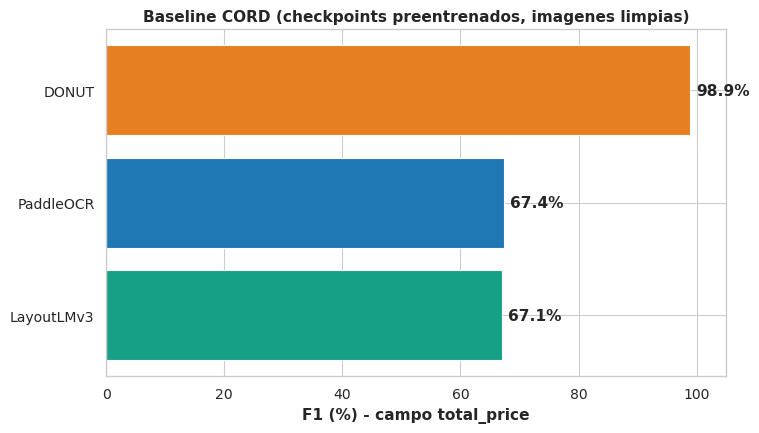

Nota: Donut y LayoutLMv3 estan finetuned en CORD; PaddleOCR es OCR+regex.


,F1,Precision,Recall,CER,ANLS
Modelo,,,,,
PaddleOCR,67.4%,67.4%,67.4%,0.244,0.674
LayoutLMv3,67.1%,96.1%,51.6%,0.484,0.516
DONUT,98.9%,100.0%,97.9%,0.021,0.979


Guardado en: /content/drive/MyDrive/STUDIES/MASTER/2Q/TFM/03__Resultados


In [ ]:
# ==============================================================================
# 07 - GRÁFICA Y TABLA RESUMEN (baseline CORD)
# ==============================================================================


import json, os
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from IPython.display import display

# Carga de los resultados agregados obtenidos durante la evaluación baseline.
with open(os.path.join(CONFIG['RESULTS_DIR'], 'baseline_cord.json'), encoding='utf-8') as f:
    B = json.load(f)
pm = B['por_modelo']

# Construcción de una tabla resumen con las principales métricas de evaluación.
df = pd.DataFrame([{'Modelo': k, 'F1': v['f1'], 'Precision': v['precision'], 'Recall': v['recall'],
                    'CER': v['cer'], 'ANLS': v['anls']} for k, v in pm.items()])

# Representación gráfica del F1-Score para comparar el rendimiento de los
# distintos modelos sobre el conjunto de datos CORD.
sns.set_theme(style='whitegrid', context='paper', font_scale=1.15)
plt.figure(figsize=(8, 4.5))
o = df.sort_values('F1')
plt.barh(o['Modelo'], o['F1']*100, color=['#16a085','#1f77b4','#e67e22'][:len(o)])
plt.xlabel('F1 (%) - campo total_price', fontweight='bold')
plt.title('Baseline CORD (checkpoints preentrenados, imagenes limpias)', fontweight='bold')
plt.xlim(0, 105)
for y, (_, row) in enumerate(o.iterrows()):
    plt.text(row['F1']*100+1, y, f"{row['F1']*100:.1f}%", va='center', fontweight='bold')

# Exportación de la figura para su inclusión en la memoria.
plt.savefig(os.path.join(CONFIG['RESULTS_DIR'], 'tfm_baseline_cord.pdf'), dpi=300, bbox_inches='tight', format='pdf')
plt.show()

# Adaptación del formato de las métricas para su visualización y posterior
# incorporación en la memoria del trabajo.
dff = df.copy()
for c in ['F1','Precision','Recall']: dff[c] = (dff[c]*100).round(1).astype(str)+'%'
dff['CER']=dff['CER'].round(3); dff['ANLS']=dff['ANLS'].round(3)
dff = dff.set_index('Modelo')
print('Nota:', B['nota'])
display(dff)

# Exportación de la tabla en formato LaTeX para su integración en la memoria.
dff.to_latex(os.path.join(CONFIG['RESULTS_DIR'], 'tfm_tabla_baseline_cord.tex'))
print('Guardado en:', CONFIG['RESULTS_DIR'])


## 08 - Análisis cualitativo de un documento

Inspección visual de un documento seleccionado aleatoriamente del conjunto de evaluación. Se compara el valor de referencia (`total_price`) con las predicciones generadas por cada modelo, tanto en su forma original como tras el proceso de normalización.

Este análisis complementa las métricas agregadas y permite identificar patrones de error que no siempre son visibles mediante indicadores cuantitativos.

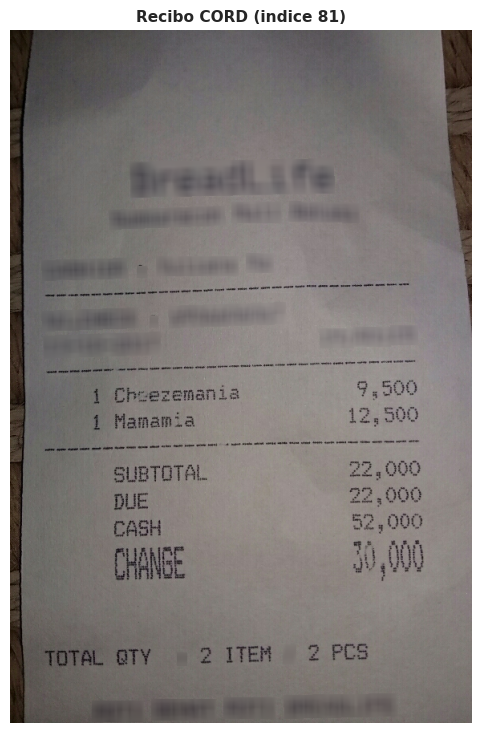

GT total_price: 22,000

  PaddleOCR    pred='30,000'  -> norm='30'  (GT norm='22')
  LayoutLMv3   pred='DUE'  -> norm=''  (GT norm='22')
  DONUT        pred='22,000'  -> norm='22'  (GT norm='22')


In [ ]:
# ==============================================================================
# 08 - ANÁLISIS CUALITATIVO DE UN DOCUMENTO
#      Comparación entre el valor de referencia y las predicciones de cada modelo.
# ==============================================================================

import random, matplotlib.pyplot as plt
random.seed(CONFIG['SEED'])
k = random.randrange(len(muestras))
plt.figure(figsize=(7, 9)); plt.imshow(muestras[k]['image']); plt.axis('off')
plt.title(f'Recibo CORD (indice {k})', fontweight='bold'); plt.show()
print(f"GT total_price: {muestras[k]['gt_total']}\n")
for modelo, preds in [('PaddleOCR', pred_paddle), ('LayoutLMv3', pred_layout), ('DONUT', pred_donut)]:
    p = preds[k]
    print(f"  {modelo:12s} pred='{p or '[vacio]'}'  -> norm='{normalizar_precio(p)}'  (GT norm='{normalizar_precio(muestras[k]['gt_total'])}')")


## 09 - Análisis de costes computacionales del baseline

Esta sección analiza los recursos computacionales empleados por cada modelo durante la fase de inferencia sobre el conjunto de datos CORD. Se consideran métricas como el tiempo de procesamiento por documento, la utilización de CPU y el consumo de memoria RAM y VRAM.

Dado que todos los modelos fueron evaluados sobre el mismo conjunto de imágenes sin degradación y bajo condiciones experimentales equivalentes, los resultados permiten realizar una comparación directa de la eficiencia computacional de los distintos enfoques.

In [ ]:
# ==============================================================================
# 09 - COSTES DE INFERENCIA EN CORD
#      Comparación de recursos y tiempos de ejecución por modelo.
# ==============================================================================

import json, os
import pandas as pd
from IPython.display import display

# Carga de las métricas de rendimiento registradas durante la inferencia.
if not os.path.exists(CONFIG['BENCH_PATH']):
    print('Aun no hay', CONFIG['BENCH_PATH'])
else:
    with open(CONFIG['BENCH_PATH']) as f: costes = json.load(f)
    df = pd.DataFrame(costes)
    if 'dataset' in df.columns:
        df = df[df['dataset'] == 'CORD']
    # Selección de los registros correspondientes a la evaluación sobre CORD.
    df = df[df['fase'] == 'inference_test']
    df = df.drop_duplicates(subset=['modelo','fase'], keep='last')
    cols = ['modelo'] + [c for c in ['s_por_item','tiempo_s','cpu_pct_medio','vram_pico_mb','ram_proc_mb_fin','n_items'] if c in df.columns]
    df = df[cols].sort_values('s_por_item').reset_index(drop=True)
    print('COSTE DE INFERENCIA EN CORD (limpio):'); display(df)
    # Exportación de los resultados agregados para su análisis posterior.
    df.to_csv(os.path.join(CONFIG['RESULTS_DIR'], 'benchmark_baseline_cord.csv'), index=False)
    print('Guardado en:', CONFIG['RESULTS_DIR'])


COSTE DE INFERENCIA EN CORD (limpio):


,modelo,s_por_item,tiempo_s,cpu_pct_medio,vram_pico_mb,ram_proc_mb_fin,n_items
0,LayoutLMv3,0.050,4.754,82.1,541.3,3278.4,95.0
1,PaddleOCR,0.247,23.464,97.7,0.0,2932.1,95.0
2,DONUT,0.891,84.640,85.4,1944.5,3415.5,95.0


Guardado en: /content/drive/MyDrive/STUDIES/MASTER/2Q/TFM/03__Resultados
